# HISTOGRAM ->
# VISUAL REPRESENTATION OF THE DISTRIBUTION OF A CONTINUOUS FEATURES

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
dark_horse = cv2.imread('../DATA/horse.jpg')
show_horse = cv2.cvtColor(dark_horse, cv2.COLOR_BGR2RGB)

rainbow = cv2.imread('../DATA/rainbow.jpg')
show_rainbow = cv2.cvtColor(rainbow, cv2.COLOR_BGR2RGB)

blue_bricks = cv2.imread('../DATA/bricks.jpg')
show_bricks = cv2.cvtColor(blue_bricks, cv2.COLOR_BGR2RGB)

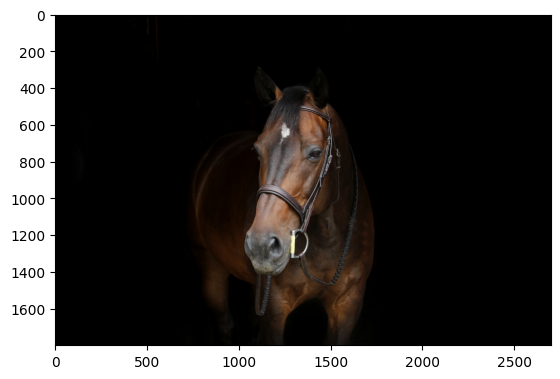

In [4]:
plt.imshow(show_horse)

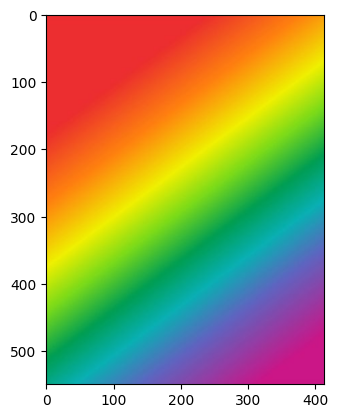

In [5]:
plt.imshow(show_rainbow)

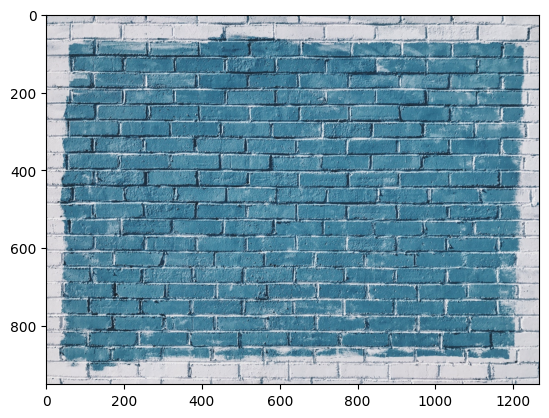

In [6]:
plt.imshow(show_bricks)

In [8]:
hist_values = cv2.calcHist([blue_bricks], channels=[0], mask=None, histSize=[256], ranges=[0, 256])

In [9]:
hist_values.shape

(256, 1)

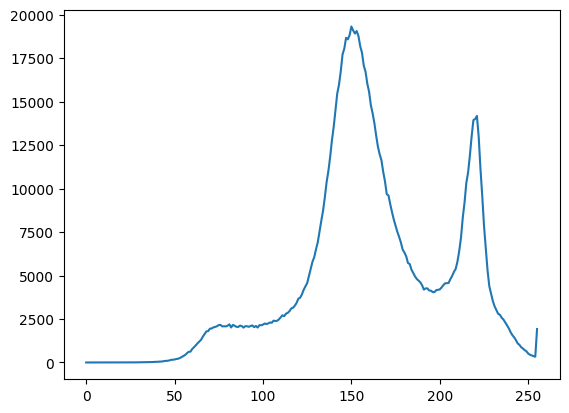

In [10]:
plt.plot(hist_values)

In [11]:
hist_values = cv2.calcHist([dark_horse], channels=[0], mask=None, histSize=[256], ranges=[0, 256])

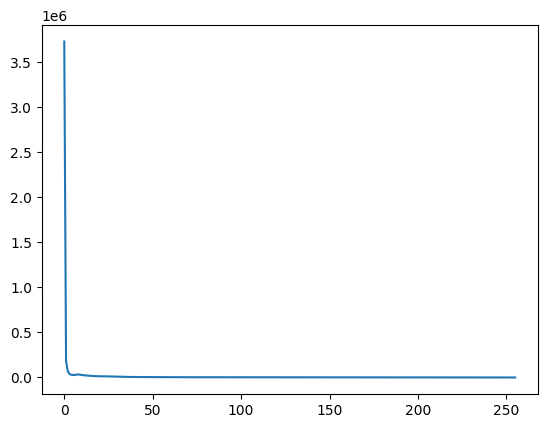

In [12]:
plt.plot(hist_values)

In [14]:
img = blue_bricks

Text(0.5, 1.0, 'HISTOGRAM FOR BRICKS')

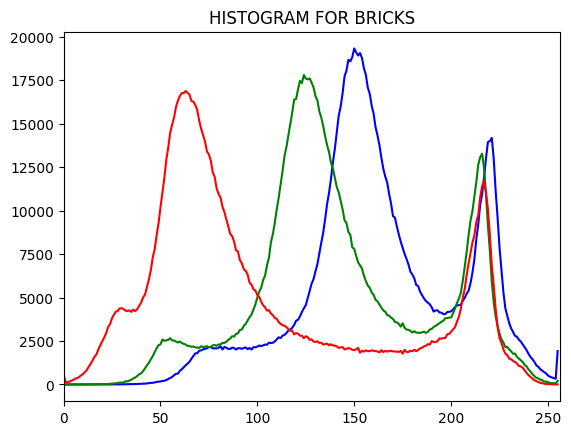

In [16]:
color = ['b', 'g', 'r']

for i, col in enumerate(color):
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist, color = col)
    plt.xlim([0, 256])

plt.title('HISTOGRAM FOR BRICKS')

In [17]:
img = dark_horse

Text(0.5, 1.0, 'HISTOGRAM FOR HORSE')

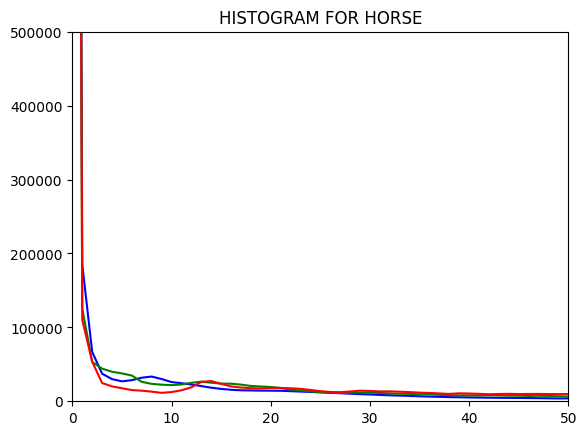

In [19]:
color = ['b', 'g', 'r']

for i, col in enumerate(color):
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist, color = col)
    plt.xlim([0, 50])
    plt.ylim([0, 500000])

plt.title('HISTOGRAM FOR HORSE')

### HISTOGRAM EQUILIZATION -> METHOD OF CONTRAST ADJUSTMENT BASED ON THE IMAGE HISTOGRAM.

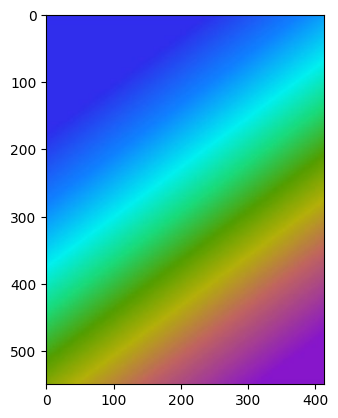

In [20]:
img = rainbow
plt.imshow(img)

In [22]:
img.shape

(550, 413, 3)

In [24]:
mask = np.zeros(img.shape[:2], np.uint8)

In [25]:
mask[300:400, 100:400] = 255

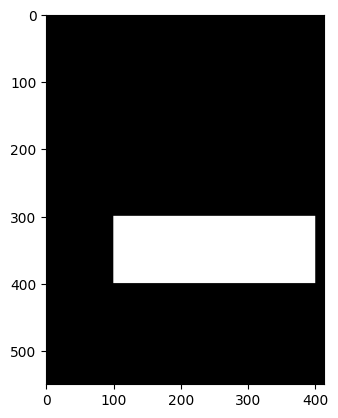

In [27]:
plt.imshow(mask, cmap='gray')

In [28]:
mask_img = cv2.bitwise_and(img, img, mask=mask)
show_masked_img = cv2.bitwise_and(show_rainbow, show_rainbow, mask=mask)

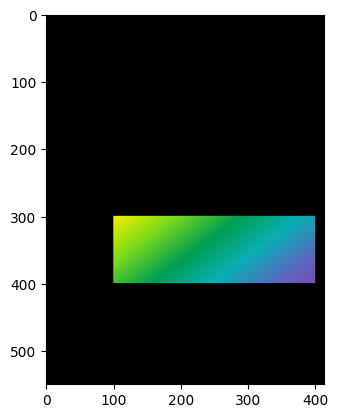

In [29]:
plt.imshow(show_masked_img)

In [33]:
hist_mask_red = cv2.calcHist([rainbow], channels=[2], mask=mask, histSize=[256], ranges=[0, 256])

In [34]:
hist_red = cv2.calcHist([rainbow], channels=[2], mask=None, histSize=[256], ranges=[0, 256])

Text(0.5, 1.0, 'Red Histogram for the masked Rainbow')

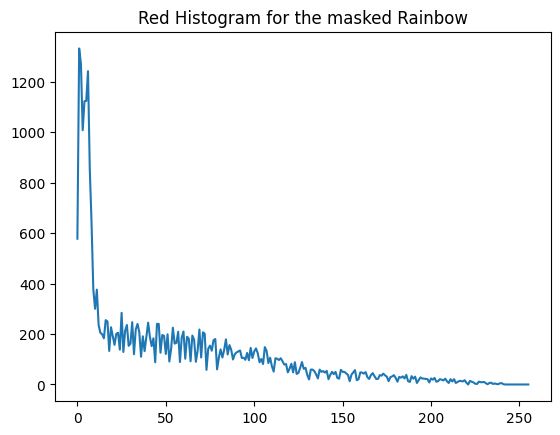

In [35]:
plt.plot(hist_mask_red)
plt.title('Red Histogram for the masked Rainbow')

Text(0.5, 1.0, 'Red histogram for noraml rainbow')

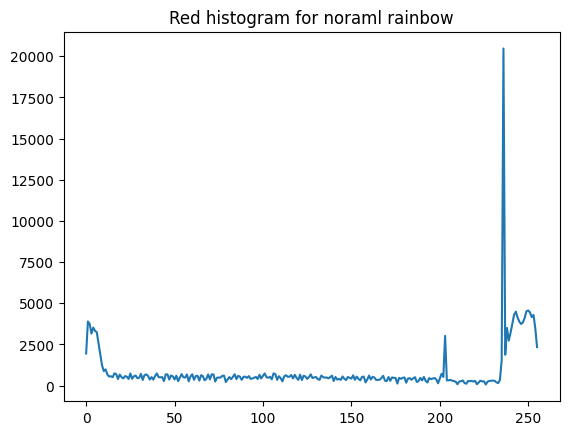

In [36]:
plt.plot(hist_red)
plt.title('Red histogram for noraml rainbow')

In [79]:
gorilla = cv2.imread('../DATA/gorilla.jpg', 0)

In [80]:
def display_img(img, cmap=None):
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap)

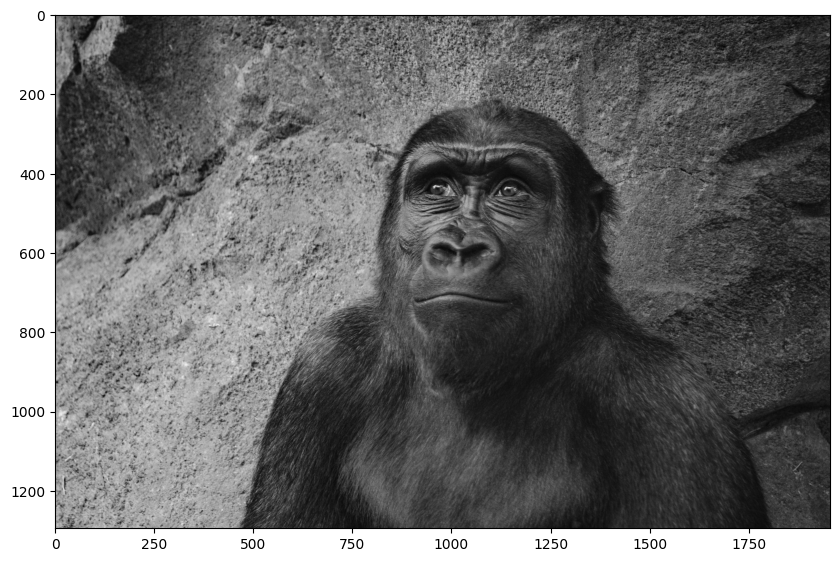

In [81]:
display_img(gorilla, 'gray')

In [84]:
hist_values = cv2.calcHist([gorilla], channels=[0], mask=None, histSize=[256], ranges=[0, 256])

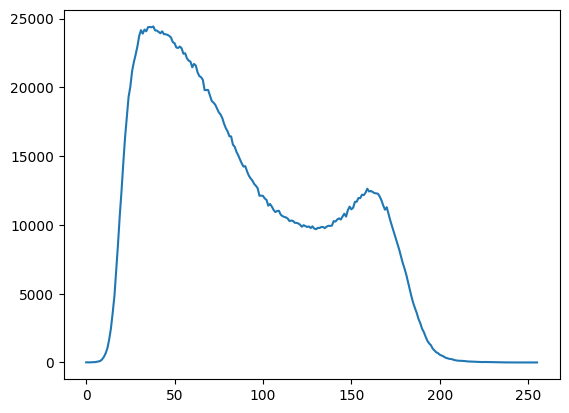

In [85]:
plt.plot(hist_values)

In [87]:
eq_gorilla = cv2.equalizeHist(gorilla)

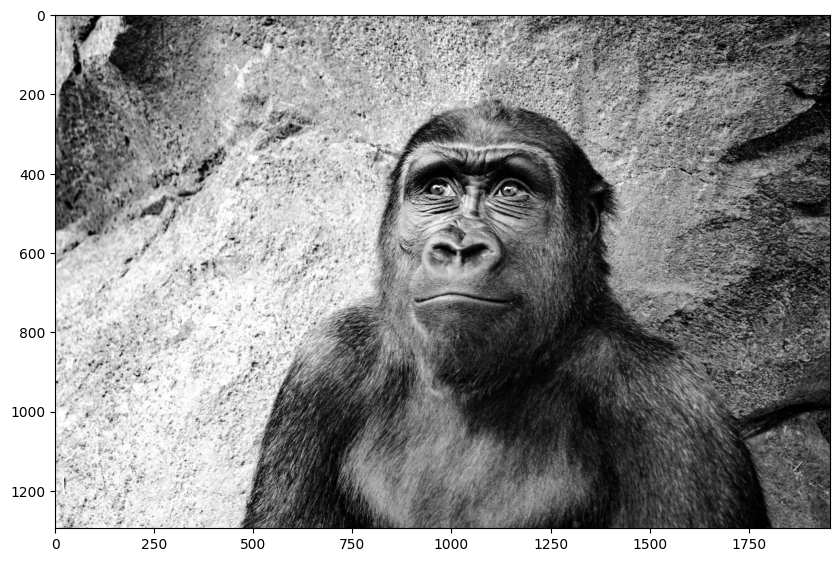

In [88]:
display_img(eq_gorilla, 'gray')

In [89]:
hist_values = cv2.calcHist([eq_gorilla], channels=[0], mask=None, histSize=[256], ranges=[0, 256])

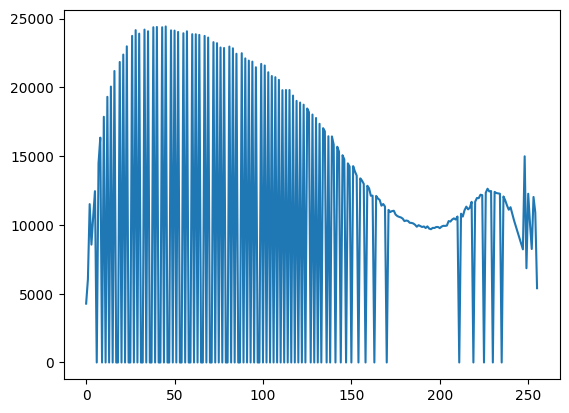

In [90]:
plt.plot(hist_values)

In [91]:
color_gorilla = cv2.imread('../DATA/gorilla.jpg')

In [108]:
hsv_gorilla = cv2.cvtColor(color_gorilla, cv2.COLOR_BGR2HSV)    # in hsv

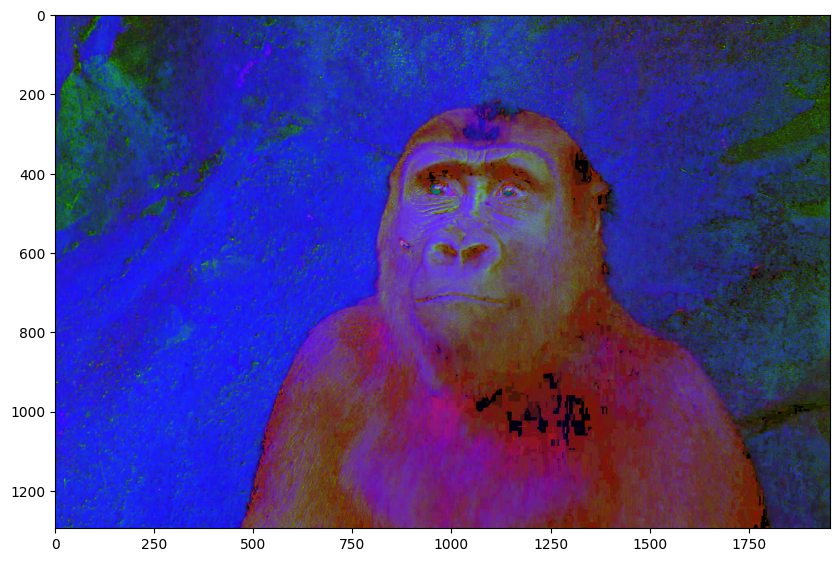

In [118]:
display_img(hsv_gorilla)

In [119]:
# Value channel helps to enhance contrast by redistributing pixel intensities more uniformly across the intensity range.
hsv_gorilla[:,:,2] = cv2.equalizeHist(hsv_gorilla[:,:,2])

In [112]:
hsv_gorilla[:,:,2].min()

np.uint8(0)

In [114]:
eq_color_gorilla = cv2.cvtColor(hsv_gorilla, cv2.COLOR_HSV2RGB)

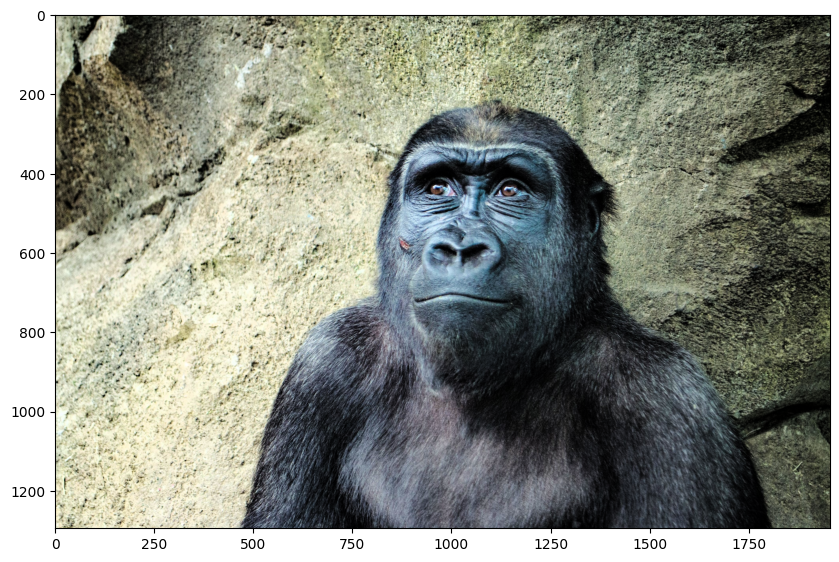

In [115]:
display_img(eq_color_gorilla)